## **Data Understanding & Exploratory Data Analysis Suara Buka Tutup**


### ***1. Import Library***

In [1]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 4)

Mempersiapkan environment untuk analisis audio dan visualisasi data,
Mengimport librosa sebagai library utama untuk pemrosesan sinyal audio,
Menyiapkan tools untuk manipulasi data (pandas), komputasi numerik (numpy), dan visualisasi (matplotlib/seaborn)

### ***2. Path Dataset***


In [2]:
DATASET_PATH = "dataset48k" 

train_path = os.path.join(DATASET_PATH, "train")
val_path   = os.path.join(DATASET_PATH, "val")

if os.path.exists(DATASET_PATH):
    print("Dataset structure:")
    if os.path.exists(train_path):
        print("Train folder :", os.listdir(train_path))
    else:
        print("Train folder tidak ditemukan!")
    
    if os.path.exists(val_path):
        print("Val folder   :", os.listdir(val_path))
    else:
        print("Val folder tidak ditemukan!")
else:
    print(f"Dataset path '{DATASET_PATH}' tidak ditemukan!")
    print("Current directory:", os.getcwd())
    print("Files in current directory:", os.listdir('.'))

Dataset structure:
Train folder : ['buka', 'tutup']
Val folder   : ['buka', 'tutup']


Memverifikasi keberadaan dataset dan struktur folder yang diperlukan,
Memeriksa organisasi data dalam format train/validation split,
Menampilkan struktur folder untuk memastikan data terorganisir dengan benar (folder "buka" dan "tutup"),
Error handling jika dataset tidak ditemukan atau struktur folder salah

### ***3. Cek distribusi data***

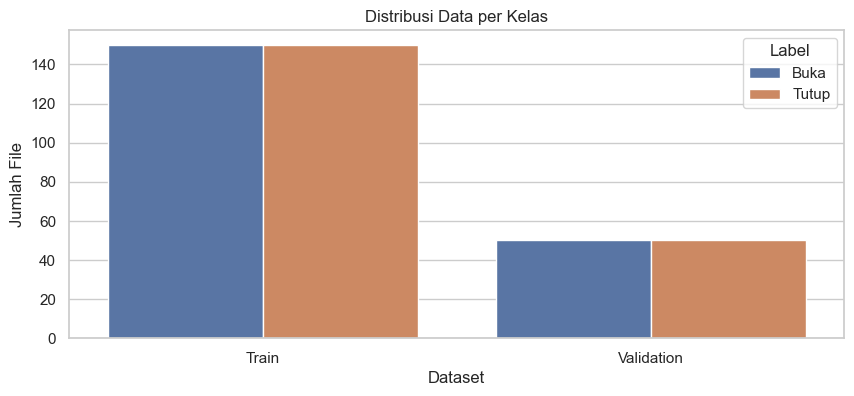

      Dataset  Buka  Tutup
0       Train   150    150
1  Validation    50     50


In [3]:
def count_files(base_path):
    counts = {}
    for label in os.listdir(base_path):
        folder = os.path.join(base_path, label)
        if os.path.isdir(folder):
            counts[label] = len(os.listdir(folder))
    return counts

train_counts = count_files(train_path)
val_counts = count_files(val_path)

# Buat dataframe untuk visualisasi
df_counts = pd.DataFrame({
    'Dataset': ['Train', 'Validation'],
    'Buka': [train_counts.get('buka', 0), val_counts.get('buka', 0)],
    'Tutup': [train_counts.get('tutup', 0), val_counts.get('tutup', 0)]
})
df_counts_melt = df_counts.melt(id_vars='Dataset', var_name='Label', value_name='Jumlah')


sns.barplot(data=df_counts_melt, x='Dataset', y='Jumlah', hue='Label')
plt.title("Distribusi Data per Kelas")
plt.ylabel("Jumlah File")
plt.show()

print(df_counts)


Menghitung jumlah sampel di setiap kelas ("buka" vs "tutup"),
Mengidentifikasi class imbalance yang dapat mempengaruhi performa model,
Membuat visualisasi bar chart untuk perbandingan distribusi data

### ***4. Contoh audio + metadata***

In [4]:
buka_example = os.path.join(train_path, "buka", os.listdir(os.path.join(train_path, "buka"))[0])
tutup_example = os.path.join(train_path, "tutup", os.listdir(os.path.join(train_path, "tutup"))[0])

print("Contoh suara 'buka'")
ipd.display(ipd.Audio(buka_example))
print("Contoh suara 'tutup'")
ipd.display(ipd.Audio(tutup_example))


Contoh suara 'buka'


Contoh suara 'tutup'


Memberikan preview audio dari masing-masing kelas untuk analisis kualitatif,
Validasi kualitas data dengan mendengar langsung sampel audio

### ***5. Analisis durasi dan sample rate***

       count      mean       std       min       25%       50%       75%  \
label                                                                      
buka   150.0  3.297835  0.644505  0.999375  2.714333  3.764354  3.764354   
tutup  150.0  3.508233  0.679784  1.674333  2.934333  3.944313  4.094333   

            max  
label            
buka   3.794292  
tutup  4.094333  


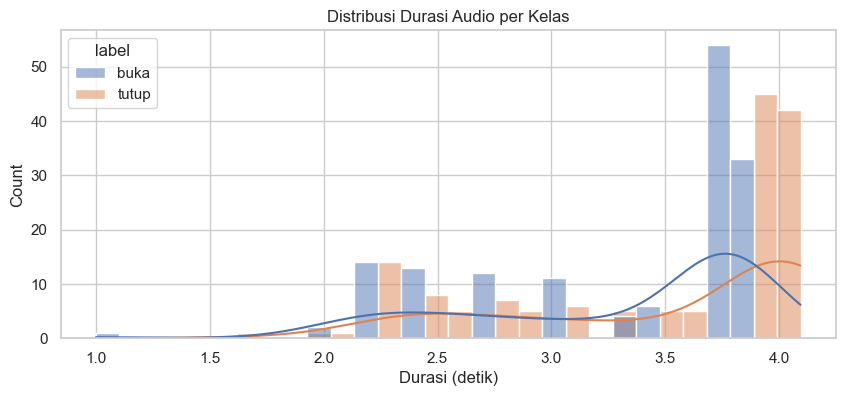


Sample rate unik: [48000]


In [5]:
def analyze_audio_stats(base_path):
    data = []
    for label in os.listdir(base_path):
        folder = os.path.join(base_path, label)
        if os.path.isdir(folder):
            for fn in os.listdir(folder):
                fp = os.path.join(folder, fn)
                y, sr = librosa.load(fp, sr=None)
                duration = len(y) / sr
                data.append({'label': label, 'sr': sr, 'duration': duration})
    return pd.DataFrame(data)

audio_stats = analyze_audio_stats(train_path)

print(audio_stats.groupby('label')['duration'].describe())

sns.histplot(data=audio_stats, x='duration', hue='label', bins=30, kde=True)
plt.title("Distribusi Durasi Audio per Kelas")
plt.xlabel("Durasi (detik)")
plt.show()

print("\nSample rate unik:", audio_stats['sr'].unique())


Menganalisis durasi audio untuk setiap file dalam dataset,
Memeriksa konsistensi sample rate di seluruh dataset,
Menghasilkan statistik deskriptif (mean, std, min, max durasi) per kelas,
Membuat histogram distribusi durasi untuk memahami variabilitas data